#### ***08 — ARMA, ARIMA, ARIMAX, AutoARIMA***

We covered the remaining models from the project rubric, following the **General Modeling Procedure** seen in class:

1. AIC grid → 2. Residual analysis (`plot_diagnostics` + Ljung-Box) → 3. Rolling forecast → 4. Metrics.

| Section | Model | Rubric requirement |
|---|---|---|
| 1 | ARMA(p, 0, q)                                          | §2 |
| 2 | ARIMA(p, 1, q) — 2 combinations                        | §3 |
| 3 | ARIMA on a deseasonalised series (naive seasonal)       | §3 |
| 4 | SARIMAX without seasonality (ARIMAX) with exogenous    | §5 |
| 5 | AutoARIMA non-seasonal                                  | §5 |
| 6 | AutoARIMA seasonal (m=7)                                | §5 |
| 7 | **Unified leaderboard** with every model in the project | §7 |

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from itertools import product
from typing import Union
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima import auto_arima
import timesfm

from scripts.metrics import compute_all
from scripts.evaluation import rolling_origin_forecast, evaluate_windows, summarise
from scripts.lstm_train import LSTMForecaster, get_device, FEATURE_COLS, TARGET_COL

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


Loaded PyTorch TimesFM, likely because python version is 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0].


#### ***Load processed data and split***

In [2]:
data = pd.read_csv('../data/processed_daily.csv', parse_dates=['date'], index_col='date')

TEST_DAYS = 30
HORIZON   = 7
SEASON    = 7

split_date = data.index.max() - pd.Timedelta(days=TEST_DAYS - 1)
train_y    = data.loc[data.index <  split_date, 'energy_kwh']
test_y     = data.loc[data.index >= split_date, 'energy_kwh']

EXOG_COLS  = ['temp_mean', 'is_weekend', 'is_holiday']
exog_full  = data[EXOG_COLS]

print(f'Train: {len(train_y)} days   Test: {len(test_y)} days   Horizon: {HORIZON}   Windows: {len(test_y)//HORIZON}')

Train: 1897 days   Test: 30 days   Horizon: 7   Windows: 4


#### ***Class-style helpers***

We wrote `optimize_*` to walk the (p, q) grid and return a dataframe sorted by AIC, and `make_sarimax_fn` to build the `forecast_fn` we reuse in `rolling_origin_forecast`.

In [3]:
def optimize_arma(endog, order_list):
    rows = []
    for p, q in order_list:
        try:
            m = SARIMAX(endog, order=(p, 0, q), simple_differencing=False).fit(disp=False)
            rows.append({'(p, q)': (p, q), 'AIC': float(m.aic)})
        except Exception:
            pass
    return pd.DataFrame(rows).sort_values('AIC').reset_index(drop=True)

def optimize_arima(endog, order_list, d):
    rows = []
    for p, q in order_list:
        try:
            m = SARIMAX(endog, order=(p, d, q), simple_differencing=False).fit(disp=False)
            rows.append({'(p, q)': (p, q), 'AIC': float(m.aic)})
        except Exception:
            pass
    return pd.DataFrame(rows).sort_values('AIC').reset_index(drop=True)

def optimize_arimax(endog, exog, order_list, d):
    rows = []
    for p, q in order_list:
        try:
            m = SARIMAX(endog, exog=exog, order=(p, d, q), simple_differencing=False).fit(disp=False)
            rows.append({'(p, q)': (p, q), 'AIC': float(m.aic)})
        except Exception:
            pass
    return pd.DataFrame(rows).sort_values('AIC').reset_index(drop=True)

def make_sarimax_fn(order, sorder=(0, 0, 0, 0), exog_frame=None):
    """Returns forecast_fn(history, h) compatible with rolling_origin_forecast."""
    def fn(history, horizon):
        ex_train = exog_frame.loc[history.index] if exog_frame is not None else None
        future_idx = pd.date_range(history.index[-1] + pd.Timedelta(days=1),
                                   periods=horizon, freq='D')
        ex_future = exog_frame.loc[future_idx] if exog_frame is not None else None
        m = SARIMAX(history, exog=ex_train, order=order, seasonal_order=sorder,
                    simple_differencing=False).fit(disp=False, maxiter=200)
        return m.forecast(steps=horizon, exog=ex_future).values
    return fn

def evaluate_rolling(name, fn, train, test, horizon=HORIZON, season=SEASON):
    windows    = rolling_origin_forecast(fn, train, test, horizon=horizon)
    per_window = evaluate_windows(windows, train, season=season)
    summary    = summarise(per_window)
    print(f'\n=== {name} ===')
    print(per_window.round(3).to_string(index=False))
    return windows, per_window, summary

leaderboard_rows = {}  # nombre -> summary

#### ***1. ARMA(p, 0, q) — model on the raw series***

The ADF test in notebook `02_stationarity` gave p = 0.022 → the series is stationary at the 5 % level, so ARMA is formally applicable (the stationarity is marginal, though, and there is a visible EV-adoption trend). We tried every (p, q) ∈ {0,1,2,3}².

In [4]:
order_list = list(product(range(0, 4), range(0, 4)))
arma_grid  = optimize_arma(train_y, order_list)
print('Top-5 ARMA(p, 0, q) por AIC:')
arma_grid.head(5)

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/t

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/t

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


...

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Top-5 ARMA(p, 0, q) por AIC:


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,"(p, q)",AIC
0,"(3, 3)",19317.454829
1,"(1, 1)",19331.547946
2,"(2, 2)",19333.510721
3,"(1, 2)",19333.541179
4,"(2, 1)",19333.541551


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Best ARMA: (3, 0, 3)  AIC=19317.5


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


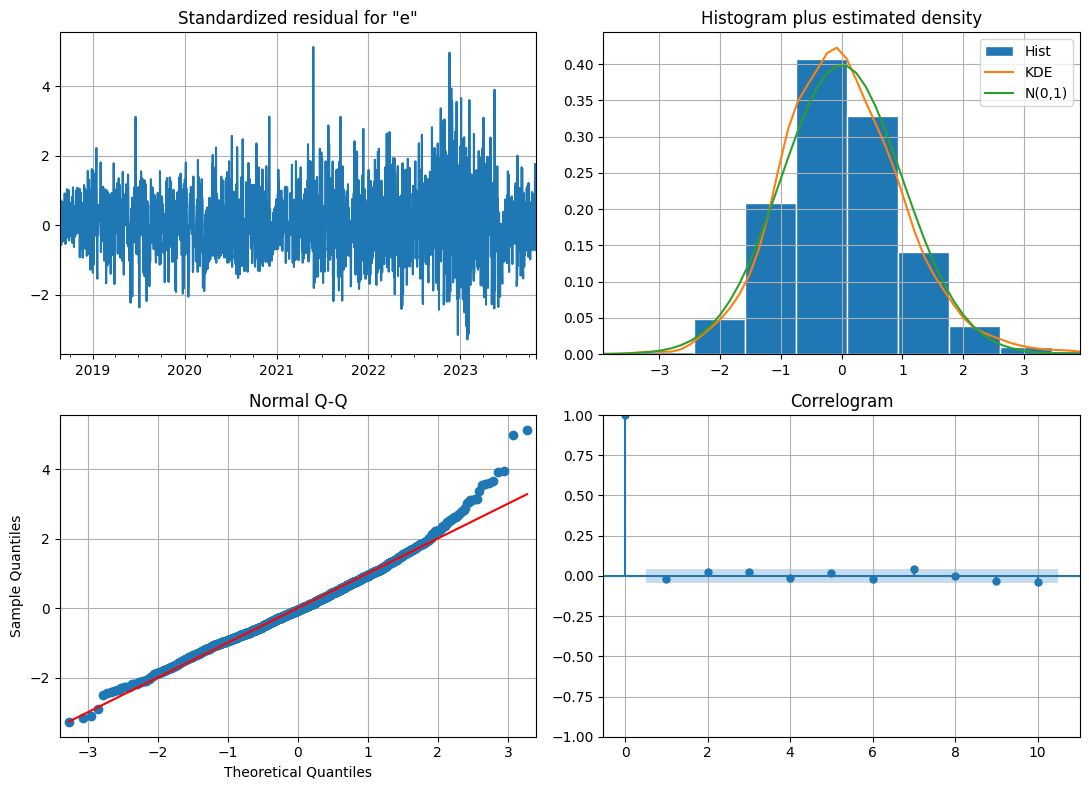

In [5]:
# Best ARMA
best_arma = tuple(arma_grid.iloc[0]['(p, q)'])
p_arma, q_arma = int(best_arma[0]), int(best_arma[1])
print(f'Best ARMA: ({p_arma}, 0, {q_arma})  AIC={arma_grid.iloc[0]["AIC"]:.1f}')

arma_model = SARIMAX(train_y, order=(p_arma, 0, q_arma), simple_differencing=False).fit(disp=False)
arma_model.plot_diagnostics(figsize=(11, 8))
plt.tight_layout(); plt.show()

In [6]:
lb = acorr_ljungbox(arma_model.resid, lags=[10, 20], return_df=True)
print('Ljung-Box (H0: residuals are white noise):')
print(lb)

Ljung-Box (H0: residuals are white noise):
      lb_stat  lb_pvalue
10  12.459244   0.255496
20  24.117771   0.237286


In [7]:
_, _, summary_arma = evaluate_rolling(f'ARMA ({p_arma}, 0, {q_arma})',
                                       make_sarimax_fn(order=(p_arma, 0, q_arma)),
                                       train_y, test_y)
leaderboard_rows[f'ARMA ({p_arma}, 0, {q_arma})'] = summary_arma

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



=== ARMA (3, 0, 3) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 15.352 17.921 0.416  0.335   3.650  0.092 0.388
      2 2023-11-07 19.395 20.353 0.623  0.460   9.735 -0.297 0.490
      3 2023-11-14 42.976 46.718 0.908  0.748 -26.081 -0.526 1.087
      4 2023-11-21 29.120 38.010 0.401  0.417 -13.806 -0.223 0.736


#### ***2. ARIMA(p, 1, q) — 2+ combinations***

We set d = 1. The ADF in notebook `02_stationarity` rejects the unit root, but only marginally (p = 0.022), and the rolling-std plot shows variance growing with the level, so first-differencing is the safer choice for an ARIMA grid. The rubric asks for **at least 2** distinct combinations; we show the top-5 from the grid and explicitly fit the best one and a second one as a contrast.

In [8]:
arima_grid = optimize_arima(train_y, order_list, d=1)
print('Top-5 ARIMA(p, 1, q) por AIC:')
arima_grid.head(5)

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/t

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/t

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/t

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/st

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Top-5 ARIMA(p, 1, q) por AIC:


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,"(p, q)",AIC
0,"(3, 3)",19305.801377
1,"(2, 3)",19306.557171
2,"(0, 1)",19319.440491
3,"(1, 2)",19321.395968
4,"(0, 2)",19321.435629


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Combo 1 (best): (3, 1, 3)  AIC=19305.8
Combo 2 (alt) : (2, 1, 3)   AIC=19306.6


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


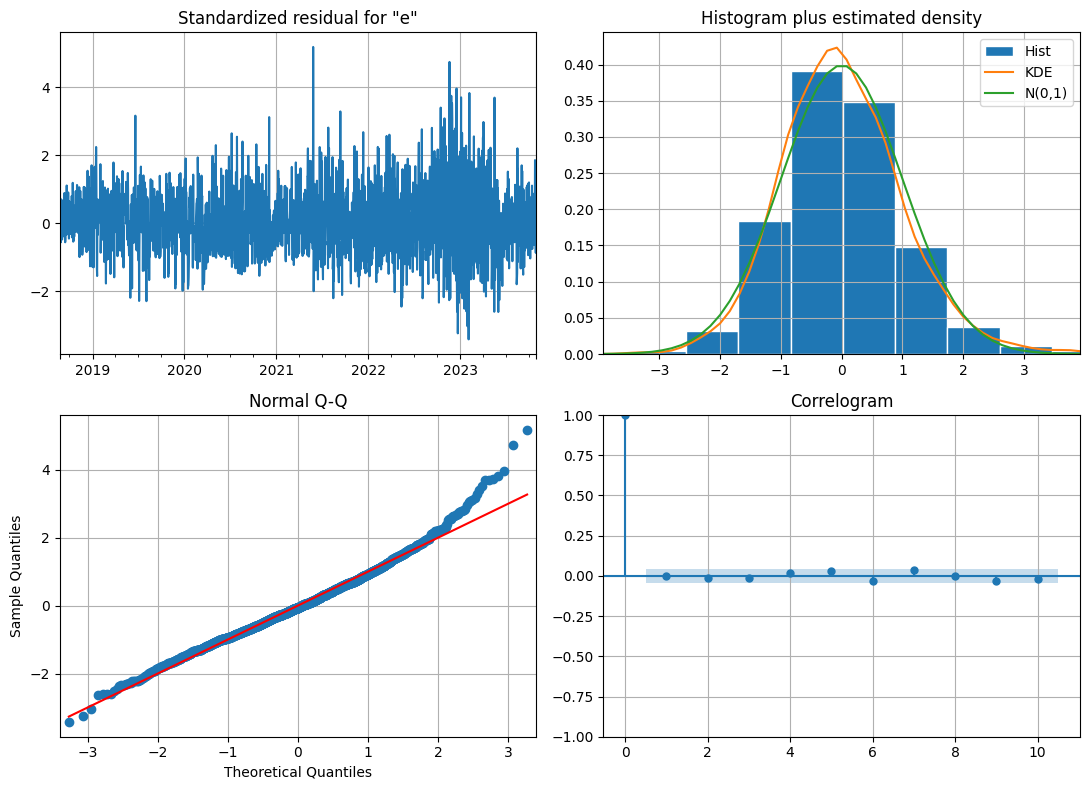

In [9]:
# Best two combos
best_arima = tuple(arima_grid.iloc[0]['(p, q)'])
alt_arima  = tuple(arima_grid.iloc[1]['(p, q)'])
print(f'Combo 1 (best): ({best_arima[0]}, 1, {best_arima[1]})  AIC={arima_grid.iloc[0]["AIC"]:.1f}')
print(f'Combo 2 (alt) : ({alt_arima[0]}, 1, {alt_arima[1]})   AIC={arima_grid.iloc[1]["AIC"]:.1f}')

# Fit and diagnose winner
arima_best = SARIMAX(train_y, order=(best_arima[0], 1, best_arima[1]),
                    simple_differencing=False).fit(disp=False)
arima_best.plot_diagnostics(figsize=(11, 8))
plt.tight_layout(); plt.show()

In [10]:
lb = acorr_ljungbox(arima_best.resid, lags=[10, 20], return_df=True)
print('Ljung-Box (best ARIMA):')
print(lb)

Ljung-Box (best ARIMA):
      lb_stat  lb_pvalue
10  10.248741   0.418948
20  25.538127   0.181613


In [11]:
# Rolling-origin evaluation: both combos
order1 = (int(best_arima[0]), 1, int(best_arima[1]))
order2 = (int(alt_arima[0]),  1, int(alt_arima[1]))

_, _, summary_arima1 = evaluate_rolling(f'ARIMA {order1}', make_sarimax_fn(order=order1), train_y, test_y)
_, _, summary_arima2 = evaluate_rolling(f'ARIMA {order2}', make_sarimax_fn(order=order2), train_y, test_y)

leaderboard_rows[f'ARIMA {order1}'] = summary_arima1
leaderboard_rows[f'ARIMA {order2}'] = summary_arima2

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



=== ARIMA (3, 1, 3) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 16.925 19.526 0.464  0.363   4.564 -0.078 0.428
      2 2023-11-07 19.867 20.912 0.641  0.468  10.500 -0.369 0.502
      3 2023-11-14 41.878 46.743 0.857  0.725 -26.591 -0.528 1.059
      4 2023-11-21 28.047 37.923 0.368  0.398 -13.241 -0.217 0.709


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



=== ARIMA (2, 1, 3) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 14.750 18.440 0.429  0.318   6.081  0.039 0.373
      2 2023-11-07 19.408 20.371 0.624  0.460   9.761 -0.299 0.491
      3 2023-11-14 43.027 46.759 0.909  0.749 -26.103 -0.529 1.088
      4 2023-11-21 28.070 37.570 0.372  0.399 -13.016 -0.194 0.710


#### ***3. ARIMA with naive seasonal handling***

Class strategy: when the series has seasonality but we do not want to add seasonal terms, we **deseasonalise manually** by computing `y_t - y_{t-7}` and fit ARIMA on the residual. At forecast time we **add the seasonal component back**. Conceptually it is the bridge between ARIMA and SARIMA.

In [12]:
# Seasonally-differenced training series
season_lag = SEASON  # 7

def make_arima_on_deseasonalised_fn(order):
    def fn(history, horizon):
        # 1) Subtract seasonal lag
        sdiff = history - history.shift(season_lag)
        sdiff = sdiff.dropna()
        # 2) Fit ARIMA on deseasonalised series
        m = SARIMAX(sdiff, order=order, simple_differencing=False).fit(disp=False, maxiter=200)
        fc_diff = m.forecast(steps=horizon).values
        # 3) Re-add seasonal lag from history (last 7 observed values, replicated as needed)
        last_seasonal = history.iloc[-season_lag:].values
        seasonal_addition = np.tile(last_seasonal, int(np.ceil(horizon / season_lag)))[:horizon]
        return fc_diff + seasonal_addition
    return fn

# Use the best ARIMA orders found above on the deseasonalised series
order_naive = order1
_, _, summary_arima_naive = evaluate_rolling(
    f'ARIMA naive-seasonal {order_naive}',
    make_arima_on_deseasonalised_fn(order_naive),
    train_y, test_y,
)
leaderboard_rows[f'ARIMA naive-seasonal {order_naive}'] = summary_arima_naive

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



=== ARIMA naive-seasonal (3, 1, 3) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 29.719 40.511 0.746  0.509   6.950 -3.640 0.751
      2 2023-11-07 24.185 28.602 0.684  0.527   5.559 -1.561 0.611
      3 2023-11-14 52.030 55.551 1.094  0.934 -31.619 -1.158 1.315
      4 2023-11-21 33.016 40.788 0.513  0.474  -0.696 -0.408 0.835


#### ***4. ARIMAX — SARIMAX without seasonality, with exogenous***

The rubric asks for SARIMAX **with and without seasonality**. We already covered the "with" version in `04_sarima` (`exog` variant of the grid). Here we cover the "without" version: ARIMAX = SARIMAX with `seasonal_order=(0, 0, 0, 0)`. Same exogenous variables: `temp_mean`, `is_weekend`, `is_holiday`.

In [13]:
arimax_grid = optimize_arimax(train_y, exog_full.loc[train_y.index], order_list, d=1)
print('Top-5 ARIMAX(p, 1, q) por AIC:')
arimax_grid.head(5)

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


...

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Top-5 ARIMAX(p, 1, q) por AIC:


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,"(p, q)",AIC
0,"(2, 3)",19274.823164
1,"(3, 3)",19276.322683
2,"(0, 1)",19287.338052
3,"(0, 2)",19288.443128
4,"(1, 1)",19288.499702


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Best ARIMAX: (2, 1, 3)  AIC=19274.8


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


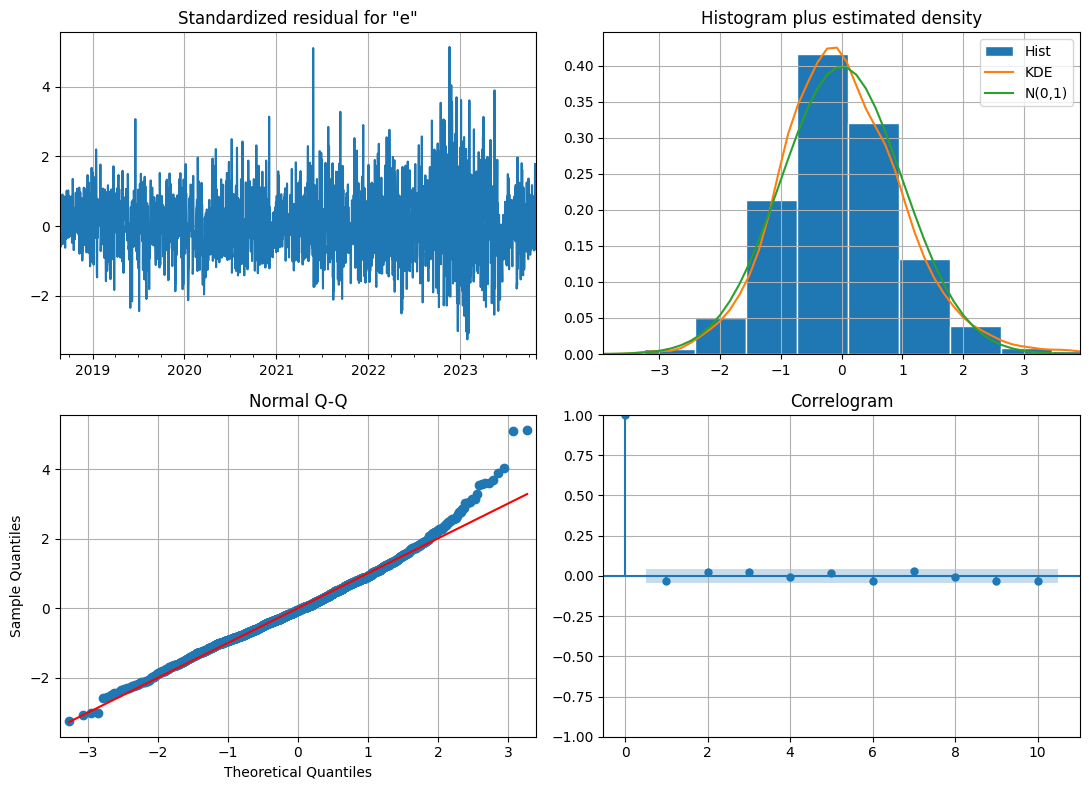

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_mean      0.3258      0.169      1.931      0.053      -0.005       0.657
is_weekend    -6.8870      2.131     -3.231      0.001     -11.064      -2.710
is_holiday   -10.2054      5.657     -1.804      0.071     -21.292       0.881
ar.L1         -0.4482      0.025    -17.622      0.000      -0.498      -0.398
ar.L2         -0.9370      0.027    -34.695      0.000      -0.990      -0.884
ma.L1         -0.4669      0.031    -14.955      0.000      -0.528      -0.406
ma.L2          0.4734      0.037     12.958      0.000       0.402       0.545
ma.L3         -0.8407      0.033    -25.590      0.000      -0.905      -0.776
sigma2      1501.2808     38.527     38.967      0.000    1425.770    1576.792


In [14]:
best_arimax = tuple(arimax_grid.iloc[0]['(p, q)'])
p_x, q_x = int(best_arimax[0]), int(best_arimax[1])
print(f'Best ARIMAX: ({p_x}, 1, {q_x})  AIC={arimax_grid.iloc[0]["AIC"]:.1f}')

arimax_model = SARIMAX(train_y, exog=exog_full.loc[train_y.index],
                       order=(p_x, 1, q_x), simple_differencing=False).fit(disp=False)
arimax_model.plot_diagnostics(figsize=(11, 8))
plt.tight_layout(); plt.show()
print(arimax_model.summary().tables[1])

In [15]:
_, _, summary_arimax = evaluate_rolling(
    f'ARIMAX ({p_x}, 1, {q_x})',
    make_sarimax_fn(order=(p_x, 1, q_x), exog_frame=exog_full),
    train_y, test_y,
)
leaderboard_rows[f'ARIMAX ({p_x}, 1, {q_x})'] = summary_arimax

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



=== ARIMAX (2, 1, 3) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 13.074 16.024 0.358  0.288   4.205  0.274 0.331
      2 2023-11-07 15.654 18.706 0.450  0.345   6.352 -0.096 0.396
      3 2023-11-14 44.399 47.557 0.974  0.776 -25.341 -0.582 1.122
      4 2023-11-21 28.940 39.769 0.373  0.415 -17.521 -0.338 0.732


#### ***5. AutoARIMA — non-seasonal version***

We ran `pmdarima.auto_arima` in stepwise mode. Equivalent to a smarter grid search with AIC + ADF + KPSS criteria to pick `d` automatically.

In [16]:
auto_ns = auto_arima(
    train_y, seasonal=False,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None, max_d=2,
    stepwise=True, suppress_warnings=True, error_action='ignore',
    information_criterion='aic',
)
print(f'AutoARIMA (non-seasonal) → order={auto_ns.order}   AIC={auto_ns.aic():.1f}')
print(auto_ns.summary().tables[1])

AutoARIMA (non-seasonal) → order=(0, 1, 1)   AIC=19319.4
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9330      0.008   -120.301      0.000      -0.948      -0.918
sigma2      1553.8894     39.964     38.882      0.000    1475.561    1632.218


In [17]:
_, _, summary_auto_ns = evaluate_rolling(
    f'AutoARIMA non-seasonal {auto_ns.order}',
    make_sarimax_fn(order=auto_ns.order),
    train_y, test_y,
)
leaderboard_rows[f'AutoARIMA non-seasonal {auto_ns.order}'] = summary_auto_ns


=== AutoARIMA non-seasonal (0, 1, 1) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 16.065 19.216 0.435  0.348   3.945 -0.044 0.406
      2 2023-11-07 19.592 20.520 0.629  0.463  10.083 -0.318 0.495
      3 2023-11-14 41.922 45.766 0.870  0.729 -25.782 -0.465 1.060
      4 2023-11-21 28.036 37.049 0.384  0.399 -13.819 -0.162 0.709


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/t

#### ***6. AutoARIMA — seasonal version (m=7)***

In [18]:
auto_s = auto_arima(
    train_y, seasonal=True, m=SEASON,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    d=None, max_d=1,
    D=None, max_D=1,
    stepwise=True, suppress_warnings=True, error_action='ignore',
    information_criterion='aic',
)
print(f'AutoARIMA (seasonal m=7) → order={auto_s.order}  seasonal_order={auto_s.seasonal_order}')
print(f'AIC={auto_s.aic():.1f}')
print(auto_s.summary().tables[1])

AutoARIMA (seasonal m=7) → order=(0, 1, 1)  seasonal_order=(1, 0, 1, 7)
AIC=19272.2
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9377      0.008   -120.258      0.000      -0.953      -0.922
ar.S.L7        0.9675      0.013     72.201      0.000       0.941       0.994
ma.S.L7       -0.9258      0.019    -48.403      0.000      -0.963      -0.888
sigma2      1511.6263     38.396     39.369      0.000    1436.371    1586.882


In [19]:
_, _, summary_auto_s = evaluate_rolling(
    f'AutoARIMA seasonal {auto_s.order}x{auto_s.seasonal_order}',
    make_sarimax_fn(order=auto_s.order, sorder=auto_s.seasonal_order),
    train_y, test_y,
)
leaderboard_rows[f'AutoARIMA seasonal {auto_s.order}x{auto_s.seasonal_order}'] = summary_auto_s

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



=== AutoARIMA seasonal (0, 1, 1)x(1, 0, 1, 7) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 16.934 18.786 0.443  0.367   1.393  0.002 0.428
      2 2023-11-07 20.650 21.727 0.627  0.485   7.521 -0.478 0.522
      3 2023-11-14 43.324 47.327 0.843  0.760 -28.308 -0.566 1.095
      4 2023-11-21 28.847 37.918 0.378  0.412 -15.884 -0.217 0.729


#### ***7. Unified leaderboard — every model in the project***

We re-ran the rest of the project's models (baselines, SARIMA, SARIMAX, LSTM, TimesFM) under the same protocol so the metrics are directly comparable. This is the **final table** for the report.

In [20]:
# ---- Baselines (notebook 03) ----
def baseline_historical_mean(h, k): return np.full(k, h.mean())
def baseline_last_value(h, k):       return np.full(k, h.iloc[-1])
def baseline_seasonal_naive(h, k):
    last = h.iloc[-SEASON:].values
    return np.tile(last, int(np.ceil(k / SEASON)))[:k]
def baseline_drift(h, k):
    T = len(h)
    return h.iloc[-1] + (h.iloc[-1] - h.iloc[0]) / (T - 1) * np.arange(1, k + 1)

for name, fn in [('Historical mean', baseline_historical_mean),
                 ('Last value',      baseline_last_value),
                 ('Seasonal naive',  baseline_seasonal_naive),
                 ('Drift',           baseline_drift)]:
    _, _, s = evaluate_rolling(name, fn, train_y, test_y)
    leaderboard_rows[name] = s


=== Historical mean ===
 window     origin    MAE   RMSE  MAPE  sMAPE   Bias     R2  MASE
      1 2023-10-31 27.018 30.935 0.812  0.503 24.561 -1.706 0.683
      2 2023-11-07 31.762 36.341 1.130  0.627 31.643 -3.135 0.803
      3 2023-11-14 31.526 37.814 1.129  0.529  0.062 -0.000 0.797
      4 2023-11-21 30.211 34.404 0.526  0.434  1.410 -0.002 0.764

=== Last value ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 20.206 27.604 0.328  0.450 -20.206 -1.154 0.511
      2 2023-11-07 25.513 29.043 0.905  0.550  22.894 -1.641 0.645
      3 2023-11-14 49.309 57.274 0.704  0.886 -43.017 -1.294 1.247
      4 2023-11-21 29.871 34.389 0.504  0.429  -0.971 -0.001 0.755

=== Seasonal naive ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 29.565 41.512 0.771  0.509   6.552 -3.872 0.747
      2 2023-11-07 20.193 25.667 0.620  0.436   7.172 -1.063 0.511
      3 2023-11-14 50.828 55.914 1.164  0.899 -31.466 -1.186 1.28

In [21]:
# ---- SARIMA / SARIMAX from the cached grid (notebook 04) ----
grid = pd.read_csv('../data/sarima_grid_results.csv')

def pick_winner(g, variant):
    sub = g[g['variant'] == variant].dropna(subset=['aic']).sort_values('aic').iloc[0]
    return (int(sub.p), int(sub.d), int(sub.q)), (int(sub.P), int(sub.D), int(sub.Q), int(sub.m))

order_s,  sorder_s  = pick_winner(grid, 'no_exog')
order_sx, sorder_sx = pick_winner(grid, 'exog')

_, _, s_sarima  = evaluate_rolling(f'SARIMA {order_s}x{sorder_s}',
                                    make_sarimax_fn(order=order_s,  sorder=sorder_s),
                                    train_y, test_y)
_, _, s_sarimax = evaluate_rolling(f'SARIMAX {order_sx}x{sorder_sx}',
                                    make_sarimax_fn(order=order_sx, sorder=sorder_sx, exog_frame=exog_full),
                                    train_y, test_y)
leaderboard_rows[f'SARIMA {order_s}x{sorder_s}']   = s_sarima
leaderboard_rows[f'SARIMAX {order_sx}x{sorder_sx}'] = s_sarimax

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



=== SARIMA (3, 1, 4)x(0, 1, 2, 7) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 16.003 19.427 0.441  0.338   4.520 -0.067 0.405
      2 2023-11-07 20.108 21.921 0.622  0.461  10.304 -0.505 0.508
      3 2023-11-14 42.861 47.446 0.867  0.750 -26.805 -0.574 1.084
      4 2023-11-21 28.460 38.867 0.378  0.404 -12.520 -0.278 0.720


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



=== SARIMAX (2, 1, 4)x(1, 1, 2, 7) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 14.754 18.513 0.408  0.318   4.256  0.031 0.373
      2 2023-11-07 18.053 20.663 0.498  0.396   6.481 -0.337 0.456
      3 2023-11-14 43.224 46.642 0.909  0.758 -25.081 -0.521 1.093
      4 2023-11-21 27.531 38.645 0.343  0.391 -17.492 -0.264 0.696


In [22]:
# ---- LSTM (notebook 05) ----
LSTM_DIR = Path('../data/lstm')
with open(LSTM_DIR / 'best_config.json') as f:
    best = json.load(f)
device = get_device()

lstm_model = LSTMForecaster(
    n_features  = len(FEATURE_COLS),
    hidden_size = best['config']['hidden_size'],
    num_layers  = best['config']['num_layers'],
    dropout     = best['config']['dropout'],
).to(device)
lstm_model.load_state_dict(torch.load(LSTM_DIR / 'best_model.pt', map_location=device))
lstm_model.eval()

SEQ_LEN    = best['config']['seq_len']
X_mean     = np.asarray(best['norms']['X_mean'], dtype=np.float32)
X_std      = np.asarray(best['norms']['X_std'],  dtype=np.float32)
Y_MEAN     = best['norms']['y_mean']
Y_STD      = best['norms']['y_std']
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)

def lstm_fn(history, horizon):
    last_date    = history.index[-1]
    past_dates   = pd.date_range(end=last_date, periods=SEQ_LEN, freq='D')
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon, freq='D')
    past_features = data.loc[past_dates,   FEATURE_COLS].values.astype(np.float32)
    future_exog   = data.loc[future_dates, FEATURE_COLS].values.astype(np.float32)
    window = (past_features - X_mean) / X_std
    preds  = []
    with torch.no_grad():
        for i in range(horizon):
            x      = torch.from_numpy(window[np.newaxis]).to(device)
            y_norm = lstm_model(x).item()
            y_pred = y_norm * Y_STD + Y_MEAN
            preds.append(y_pred)
            nf              = future_exog[i].copy()
            nf[TARGET_IDX]  = y_pred
            nfn             = (nf - X_mean) / X_std
            window          = np.concatenate([window[1:], nfn[np.newaxis]], axis=0)
    return np.asarray(preds, dtype=float)

_, _, s_lstm = evaluate_rolling(f'LSTM {best["name"]}', lstm_fn, train_y, test_y)
leaderboard_rows[f'LSTM {best["name"]}'] = s_lstm


=== LSTM seq14_h64_l2 ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 14.356 16.967 0.347  0.314  -1.262  0.186 0.363
      2 2023-11-07 20.411 21.890 0.625  0.475   9.121 -0.500 0.516
      3 2023-11-14 38.780 41.887 0.911  0.669 -19.439 -0.227 0.980
      4 2023-11-21 29.163 33.140 0.494  0.421  -0.158  0.071 0.737


In [23]:
# ---- TimesFM 2.0 (notebook 06) ----
tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend                  = 'gpu' if torch.cuda.is_available() else 'cpu',
        per_core_batch_size      = 32,
        horizon_len              = HORIZON,
        num_layers               = 50,
        use_positional_embedding = False,
        context_len              = 192,
    ),
    checkpoint=timesfm.TimesFmCheckpoint(huggingface_repo_id='google/timesfm-2.0-500m-pytorch'),
)

def tfm_fn(history, horizon):
    context = [history.values.astype(np.float32)]
    point, _ = tfm.forecast(context, freq=[0])
    return point[0][:horizon]

_, _, s_tfm = evaluate_rolling('TimesFM 2.0 (zero-shot)', tfm_fn, train_y, test_y)
leaderboard_rows['TimesFM 2.0 (zero-shot)'] = s_tfm

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]


=== TimesFM 2.0 (zero-shot) ===
 window     origin    MAE   RMSE  MAPE  sMAPE    Bias     R2  MASE
      1 2023-10-31 15.793 18.441 0.413  0.344   1.975  0.039 0.399
      2 2023-11-07 17.434 18.587 0.524  0.422   5.260 -0.082 0.441
      3 2023-11-14 43.058 47.451 0.836  0.753 -28.796 -0.575 1.089
      4 2023-11-21 28.631 38.683 0.367  0.408 -17.274 -0.266 0.724


#### ***8. Final results table***

Same metrics for every model (MAE, RMSE, MAPE, sMAPE, MASE, Bias, R²) — rolling-origin protocol with a 7-day horizon and 4 windows in the test set.

In [24]:
def fmt_pm(s, m):
    return f'{s[f"{m}_mean"]:.2f} ± {s[f"{m}_std"]:.2f}'

def fmt_pct(s, m):
    return f'{s[f"{m}_mean"]*100:5.1f}% ± {s[f"{m}_std"]*100:4.1f}%'

leaderboard = pd.DataFrame({
    name: {
        'MAE':   fmt_pm(s, 'MAE'),
        'RMSE':  fmt_pm(s, 'RMSE'),
        'MAPE':  fmt_pct(s, 'MAPE'),
        'sMAPE': fmt_pct(s, 'sMAPE'),
        'MASE':  fmt_pm(s, 'MASE'),
        'Bias':  f'{s["Bias_mean"]:+.2f}',
        'R²':    f'{s["R2_mean"]:+.2f}',
    } for name, s in leaderboard_rows.items()
}).T

leaderboard['_mase'] = [leaderboard_rows[n]['MASE_mean'] for n in leaderboard.index]
leaderboard = leaderboard.sort_values('_mase').drop(columns='_mase')
leaderboard

,MAE,RMSE,MAPE,sMAPE,MASE,Bias,R²
"ARIMAX (2, 1, 3)",25.52 ± 14.38,30.51 ± 15.55,53.9% ± 29.3%,45.6% ± 22.0%,0.65 ± 0.36,-8.08,-0.19
LSTM seq14_h64_l2,25.68 ± 10.64,28.47 ± 11.22,59.4% ± 24.0%,47.0% ± 14.9%,0.65 ± 0.27,-2.93,-0.12
"SARIMAX (2, 1, 4)x(1, 1, 2, 7)",25.89 ± 12.76,31.12 ± 13.73,54.0% ± 25.4%,46.6% ± 19.8%,0.65 ± 0.32,-7.96,-0.27
TimesFM 2.0 (zero-shot),26.23 ± 12.59,30.79 ± 14.62,53.5% ± 21.1%,48.2% ± 18.4%,0.66 ± 0.32,-9.71,-0.22
"ARIMA (2, 1, 3)",26.31 ± 12.43,30.78 ± 13.69,58.3% ± 24.2%,48.1% ± 18.8%,0.67 ± 0.31,-5.82,-0.25
"AutoARIMA non-seasonal (0, 1, 1)",26.40 ± 11.50,30.64 ± 12.95,57.9% ± 22.0%,48.5% ± 16.9%,0.67 ± 0.29,-6.39,-0.25
"ARIMA (3, 1, 3)",26.68 ± 11.17,31.28 ± 13.28,58.2% ± 21.5%,48.9% ± 16.3%,0.67 ± 0.28,-6.19,-0.30
"ARMA (3, 0, 3)",26.71 ± 12.29,30.75 ± 13.91,58.7% ± 23.7%,49.0% ± 17.9%,0.68 ± 0.31,-6.63,-0.24
"SARIMA (3, 1, 4)x(0, 1, 2, 7)",26.86 ± 11.86,31.92 ± 13.48,57.7% ± 21.9%,48.8% ± 18.2%,0.68 ± 0.30,-6.13,-0.36
"AutoARIMA seasonal (0, 1, 1)x(1, 0, 1, 7)",27.44 ± 11.70,31.44 ± 13.53,57.3% ± 20.9%,50.6% ± 17.6%,0.69 ± 0.30,-8.82,-0.31


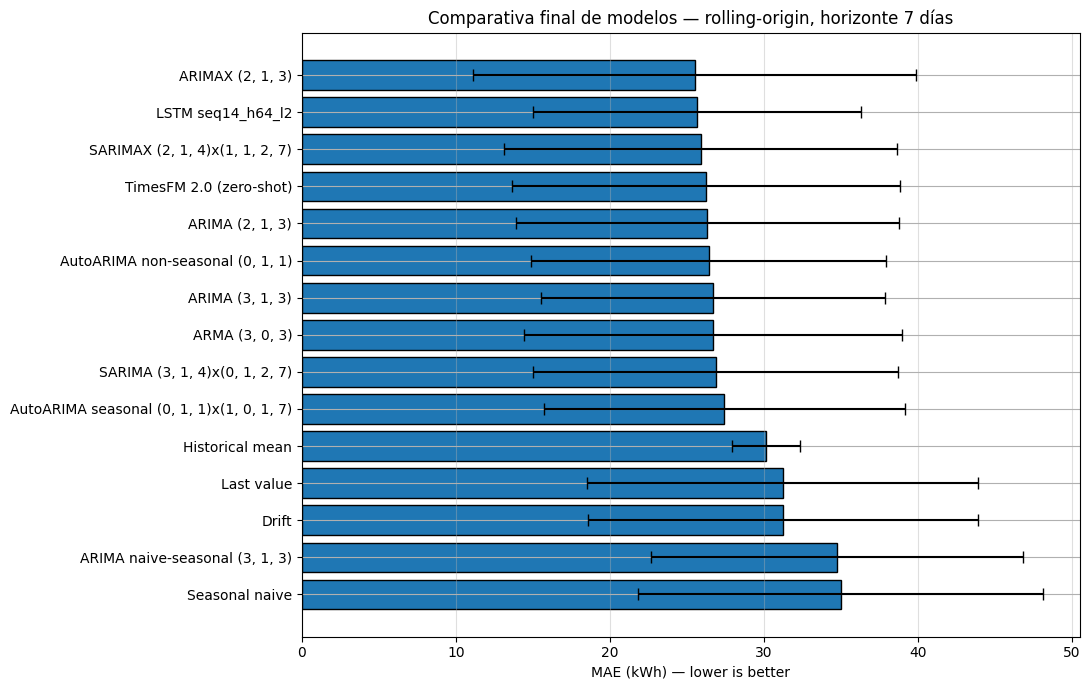

In [25]:
# Visualisation: MAE comparison
mae_means = pd.Series({n: leaderboard_rows[n]['MAE_mean'] for n in leaderboard.index})
mae_stds  = pd.Series({n: leaderboard_rows[n]['MAE_std']  for n in leaderboard.index})

fig, ax = plt.subplots(figsize=(11, 7))
y_pos = np.arange(len(mae_means))
ax.barh(y_pos, mae_means.values, xerr=mae_stds.values, capsize=4, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(mae_means.index)
ax.invert_yaxis()
ax.set_xlabel('MAE (kWh) — lower is better')
ax.set_title('Comparativa final de modelos — rolling-origin, horizonte 7 días')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()

#### ***9. Mapping to the project rubric***

| Section | Covered in |
|---|---|
| 1. Time-series analysis + decomposition  | `00_eda`, `02_stationarity` |
| 2. ARMA                                  | §1 here |
| 3. ARIMA — 2+ combos / naive seasonal    | §2, §3 here |
| 4. SARIMA                                | `04_sarima` (`no_exog`) |
| 5. SARIMAX with / without seasonality    | `04_sarima` (`exog`) / §4 (ARIMAX) here |
| 5. AutoARIMA non-seasonal / seasonal     | §5, §6 here |
| 6. Transformer                           | `06_google_vs_amazon`, `09_sota_patchtst_stacking` |
| 7. Results + baselines                   | §7–8 here |

**Extras** we added on top of the rubric: LSTM with GPU sweep (`05`), ensemble + prediction intervals (`07`), PatchTST SoTA (`09`), and a broader metric panel (MAE, RMSE, MAPE, sMAPE, MASE, Bias, R²) instead of MAPE alone.